# Горкунов Николай Максимович ИУ5-21М

# CO2 Emission by Vehicles: target encoding и диаграмма рассеяния

Задача: исследовать датасет на пропуски, выполнить target / mean encoding одного категориального признака и построить диаграмму рассеяния для пары колонок.

## 1. Импорт библиотек и настройки

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", str(Path("results/matplotlib").resolve()))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from category_encoders.target_encoder import TargetEncoder as ce_TargetEncoder

sns.set_theme(style="whitegrid")

In [2]:
DATA_PATH = Path("data/CO2_Emissions_Canada.csv")
RESULTS_DIR = Path("results")
TARGET_COLUMN = "CO2 Emissions(g/km)"
CATEGORY_COLUMN = "Make"
ENCODED_COLUMN = "Make_mean_encoded"

RESULTS_DIR.mkdir(exist_ok=True)

## 2. Загрузка и первичный осмотр данных

In [3]:
data = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {data.shape[0]} строк, {data.shape[1]} колонок")
data.head()

Размер датасета: 7385 строк, 12 колонок


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   str    
 1   Model                             7385 non-null   str    
 2   Vehicle Class                     7385 non-null   str    
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   str    
 6   Fuel Type                         7385 non-null   str    
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: float64(4), in

In [5]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Make,7385,42,FORD,628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,7385,2053,F-150 FFV,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Class,7385,16,SUV - SMALL,1217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine Size(L),7385.0,NaN,NaN,NaN,3.160068,1.35417,0.9,2.0,3.0,3.7,8.4
Cylinders,7385.0,NaN,NaN,NaN,5.61503,1.828307,3.0,4.0,6.0,6.0,16.0
Transmission,7385,27,AS6,1324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Type,7385,5,X,3637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Consumption City (L/100 km),7385.0,NaN,NaN,NaN,12.556534,3.500274,4.2,10.1,12.1,14.6,30.6
Fuel Consumption Hwy (L/100 km),7385.0,NaN,NaN,NaN,9.041706,2.224456,4.0,7.5,8.7,10.2,20.6
Fuel Consumption Comb (L/100 km),7385.0,NaN,NaN,NaN,10.975071,2.892506,4.1,8.9,10.6,12.6,26.1


## 3. Проверка пропусков

Проверим явные пропуски `NaN` во всех колонках и отдельно пустые строки в категориальных признаках. Пустая строка не всегда считается `NaN`, но для анализа она также может быть неинформативным пропуском.

In [6]:
missing_report = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_percent": (data.isna().mean() * 100).round(2),
    "dtype": data.dtypes.astype(str),
})
missing_report

,missing_count,missing_percent,dtype
Make,0,0.0,str
Model,0,0.0,str
Vehicle Class,0,0.0,str
Engine Size(L),0,0.0,float64
Cylinders,0,0.0,int64
Transmission,0,0.0,str
Fuel Type,0,0.0,str
Fuel Consumption City (L/100 km),0,0.0,float64
Fuel Consumption Hwy (L/100 km),0,0.0,float64
Fuel Consumption Comb (L/100 km),0,0.0,float64


In [7]:
categorical_columns = data.select_dtypes(include="str").columns
empty_string_report = (
    data[categorical_columns]
    .apply(lambda column: column.astype(str).str.strip().eq("").sum())
    .rename("empty_string_count")
    .to_frame()
)
empty_string_report

,empty_string_count
Make,0
Model,0
Vehicle Class,0
Transmission,0
Fuel Type,0


In [8]:
total_missing = int(missing_report["missing_count"].sum())
total_empty_strings = int(empty_string_report["empty_string_count"].sum())

print(f"Явных пропусков NaN: {total_missing}")
print(f"Пустых строк в категориальных колонках: {total_empty_strings}")

Явных пропусков NaN: 0
Пустых строк в категориальных колонках: 0


Вывод по пропускам: в датасете нет явных `NaN` и нет пустых строк в категориальных колонках. Следовательно, пропуски отсутствуют и не требуют удаления строк, удаления колонок или заполнения средним/модой. Все признаки можно использовать в дальнейшем анализе без дополнительной обработки пропусков.

## 4. Target / mean encoding категориального признака

Закодируем категориальный признак `Make`. Целевой признак - `CO2 Emissions(g/km)`. При mean encoding каждая марка автомобиля заменяется средним значением выбросов CO2 для этой марки.

Используем `TargetEncoder` из `category_encoders`. Параметры `min_samples_leaf=1` и `smoothing=0` дают обычное среднее по категории без сглаживания к глобальному среднему.

In [9]:
mean_encoder = ce_TargetEncoder(
    cols=[CATEGORY_COLUMN],
    min_samples_leaf=1,
    smoothing=0,
)

encoded_make = mean_encoder.fit_transform(data[[CATEGORY_COLUMN]], data[TARGET_COLUMN])

encoded_data = data.copy()
encoded_data[ENCODED_COLUMN] = encoded_make[CATEGORY_COLUMN]

encoded_data[[CATEGORY_COLUMN, TARGET_COLUMN, ENCODED_COLUMN]].head(10)

,Make,CO2 Emissions(g/km),Make_mean_encoded
0,ACURA,196,223.652778
1,ACURA,221,223.652778
2,ACURA,136,223.652778
3,ACURA,255,223.652778
4,ACURA,244,223.652778
5,ACURA,230,223.652778
6,ACURA,232,223.652778
7,ACURA,255,223.652778
8,ACURA,267,223.652778
9,ACURA,212,223.652778


Проверим корректность кодирования: сравним значение, которое вернул `TargetEncoder`, с ручным расчетом среднего `CO2 Emissions(g/km)` по каждой марке.

In [10]:
manual_mean = data.groupby(CATEGORY_COLUMN)[TARGET_COLUMN].mean().rename("manual_mean")
encoded_mean = encoded_data.groupby(CATEGORY_COLUMN)[ENCODED_COLUMN].first().rename("encoded_value")

encoding_check = pd.concat([manual_mean, encoded_mean], axis=1)
encoding_check["abs_diff"] = (encoding_check["manual_mean"] - encoding_check["encoded_value"]).abs()
encoding_check.sort_values("manual_mean", ascending=False).head(10)

,manual_mean,encoded_value,abs_diff
Make,,,
BUGATTI,522.000000,522.000000,0.0
LAMBORGHINI,400.780488,400.780488,0.0
SRT,389.000000,389.000000,0.0
ROLLS-ROYCE,388.480000,388.480000,0.0
BENTLEY,362.934783,362.934783,0.0
ASTON MARTIN,339.617021,339.617021,0.0
MASERATI,318.147541,318.147541,0.0
GMC,299.917683,299.917683,0.0
RAM,292.402062,292.402062,0.0


In [11]:
print("Максимальное расхождение между ручным mean encoding и TargetEncoder:", encoding_check["abs_diff"].max())

Максимальное расхождение между ручным mean encoding и TargetEncoder: 0.0


## 5. Диаграмма рассеяния

Для диаграммы рассеяния возьмем числовые колонки `Engine Size(L)` и `CO2 Emissions(g/km)`. Цветом дополнительно отметим тип топлива `Fuel Type`.

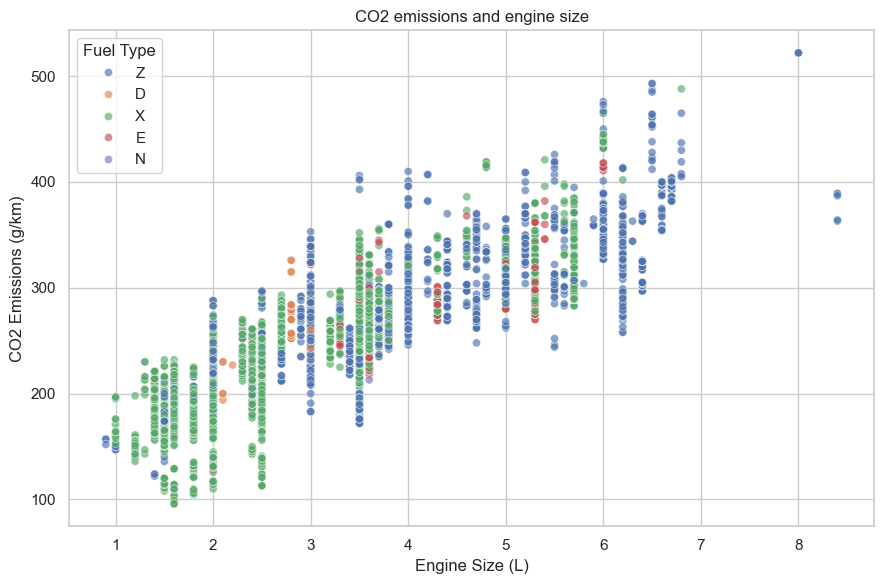

In [12]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=encoded_data,
    x="Engine Size(L)",
    y=TARGET_COLUMN,
    hue="Fuel Type",
    alpha=0.65,
    s=35,
)
plt.title("CO2 emissions and engine size")
plt.xlabel("Engine Size (L)")
plt.ylabel("CO2 Emissions (g/km)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "scatter_engine_size_co2.png", dpi=200)
plt.show()

## 6. Сохранение результатов

In [13]:
encoded_data.to_csv(RESULTS_DIR / "co2_emissions_with_mean_encoding.csv", index=False)
encoding_check.reset_index().to_csv(RESULTS_DIR / "mean_encoding_by_make.csv", index=False)

summary = [
    "Target / mean encoding",
    f"Dataset rows: {len(data)}",
    f"Dataset columns: {data.shape[1]}",
    f"NaN missing values: {total_missing}",
    f"Empty strings in categorical columns: {total_empty_strings}",
    "Missing-value decision: no deletion or imputation is required",
    f"Encoded categorical column: {CATEGORY_COLUMN}",
    f"Target column: {TARGET_COLUMN}",
    f"New column: {ENCODED_COLUMN}",
    "",
    "First encoded values:",
    encoded_data[[CATEGORY_COLUMN, TARGET_COLUMN, ENCODED_COLUMN]].head(10).to_string(index=False),
    "",
    "Files:",
    "results/co2_emissions_with_mean_encoding.csv",
    "results/mean_encoding_by_make.csv",
    "results/scatter_engine_size_co2.png",
]
(RESULTS_DIR / "summary.txt").write_text("\n".join(summary), encoding="utf-8")
print("\n".join(summary))

Target / mean encoding
Dataset rows: 7385
Dataset columns: 12
NaN missing values: 0
Empty strings in categorical columns: 0
Missing-value decision: no deletion or imputation is required
Encoded categorical column: Make
Target column: CO2 Emissions(g/km)
New column: Make_mean_encoded

First encoded values:
 Make  CO2 Emissions(g/km)  Make_mean_encoded
ACURA                  196         223.652778
ACURA                  221         223.652778
ACURA                  136         223.652778
ACURA                  255         223.652778
ACURA                  244         223.652778
ACURA                  230         223.652778
ACURA                  232         223.652778
ACURA                  255         223.652778
ACURA                  267         223.652778
ACURA                  212         223.652778

Files:
results/co2_emissions_with_mean_encoding.csv
results/mean_encoding_by_make.csv
results/scatter_engine_size_co2.png
